In [24]:
!pip -q install xgboost==3.0.5 shap==0.47.2 pandas numpy matplotlib

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import shap

In [30]:
CSV_PATH = "store_locations_test.csv"
MODEL_PATH = "store_model_A.json"

df = pd.read_csv(CSV_PATH)

feature_cols = [
    "is_franchise","store_size_sqm","planned_employees","parking_spots","opening_hours_per_week",
    "distance_to_city_center_km","distance_to_highway_km","distance_to_main_road_km","public_transport_score",
    "competition_count_1km","competition_count_5km","foot_traffic_index","nearby_shops_count_500m",
    "is_mall_location","population_density","median_income","age_distribution_index","unemployment_rate",
    "rent_per_sqm","property_tax_index",
    "country_Furtavia","region_Bathing-Wuerttemberg","region_Beerlin","region_Dark_Forest","region_Freeburg","region_Shire",
    "city_tier_metro","city_tier_rural","city_tier_suburban","city_tier_urban",
    "store_type_convenience","store_type_outlet","store_type_specialty","store_type_supermarket",
]

X = df[feature_cols].copy()

# Force fully numeric matrix for SHAP:
# bool -> int, then float32
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(np.int8)
X = X.astype(np.float32)

X.dtypes.value_counts()

float32    34
Name: count, dtype: int64

In [27]:
booster = xgb.Booster()
booster.load_model(MODEL_PATH)

In [32]:
# Use a sample for speed
X_exp = X.sample(min(1000, len(X)), random_state=42)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_exp)

# Normalize possible list output
sv = np.array(shap_values[0]) if isinstance(shap_values, list) else np.array(shap_values)

print("sv shape:", sv.shape)
print("X_exp shape:", X_exp.shape)

sv shape: (1000, 34)
X_exp shape: (1000, 34)


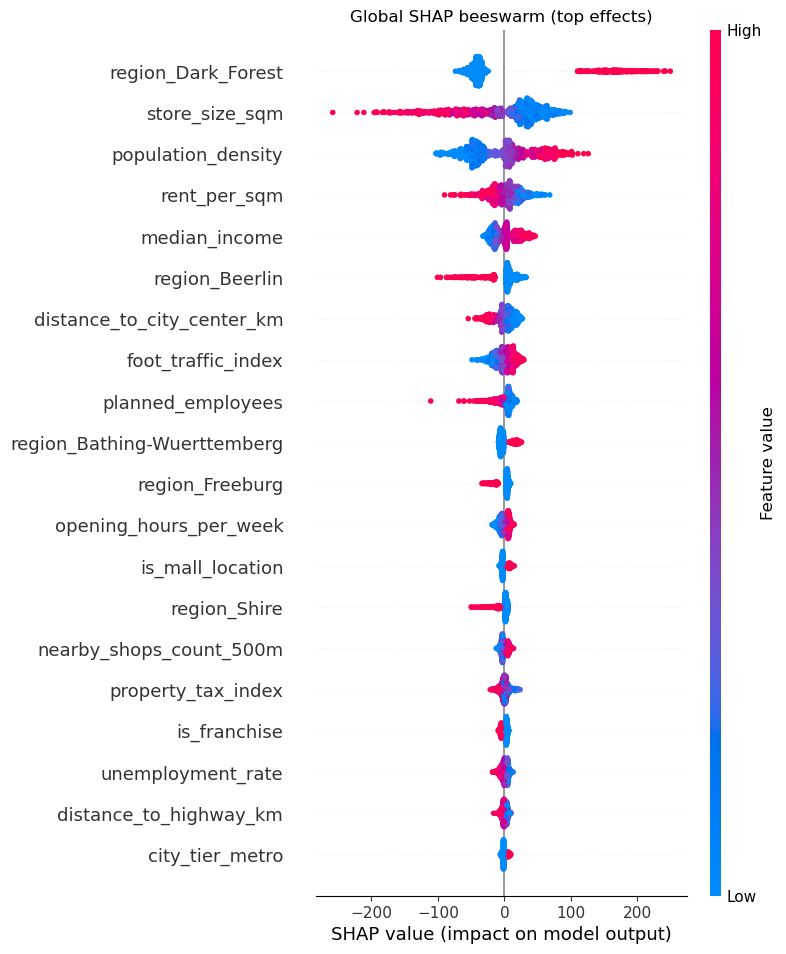

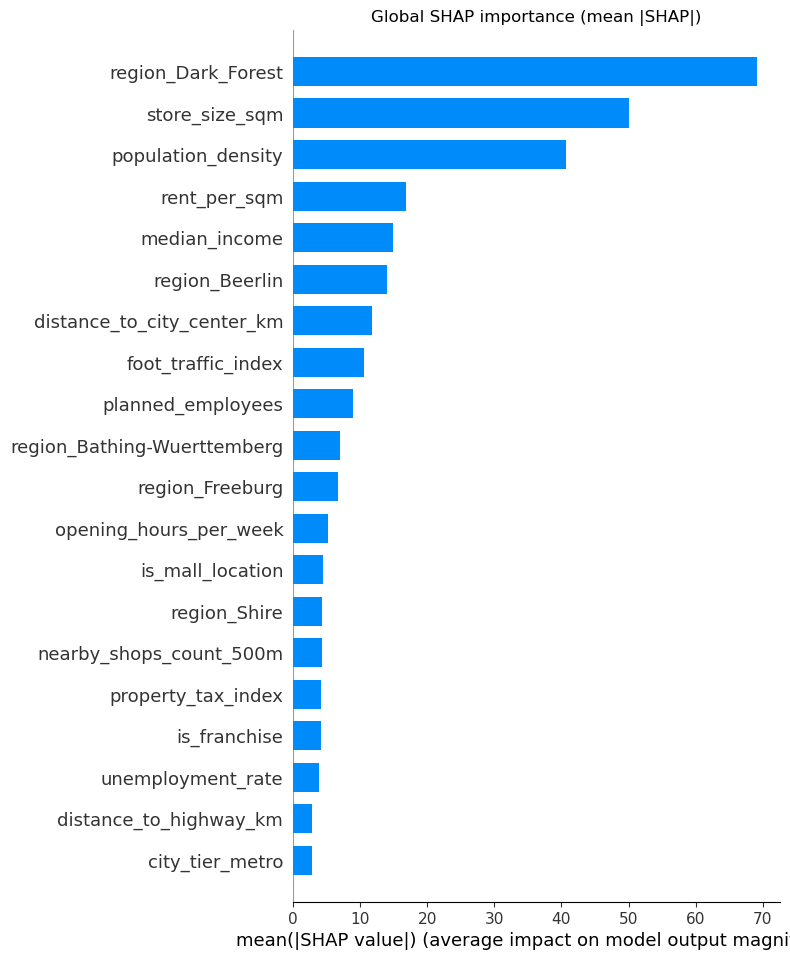

In [33]:
shap.summary_plot(sv, X_exp, show=False)
plt.title("Global SHAP beeswarm (top effects)")
plt.show()

shap.summary_plot(sv, X_exp, plot_type="bar", show=False)
plt.title("Global SHAP importance (mean |SHAP|)")
plt.show()

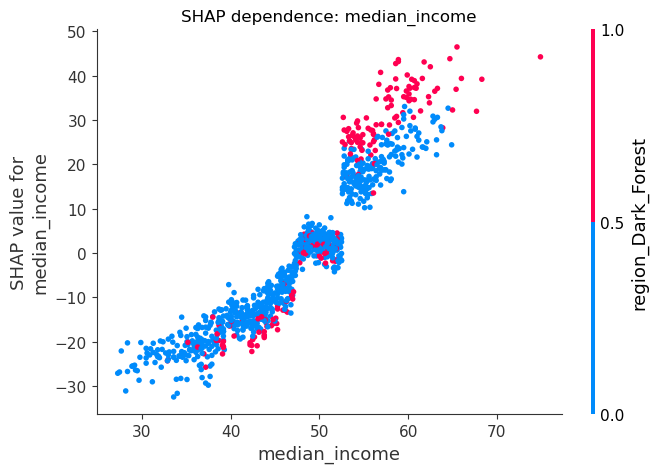

In [34]:
shap.dependence_plot("median_income", sv, X_exp, show=False)
plt.title("SHAP dependence: median_income")
plt.show()

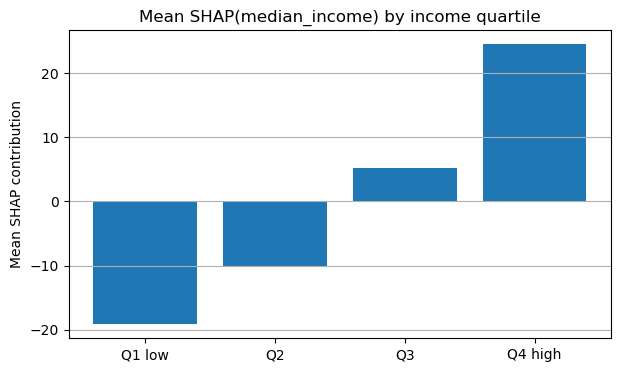

,mean,count
income_group,,
Q1 low,-19.156675,253
Q2,-10.113396,250
Q3,5.218322,250
Q4 high,24.473238,247


In [35]:
tmp = pd.DataFrame({
    "median_income": X_exp["median_income"].values,
    "shap_income": sv[:, X_exp.columns.get_loc("median_income")]
})
tmp["income_group"] = pd.qcut(tmp["median_income"], q=4, labels=["Q1 low","Q2","Q3","Q4 high"])

grp = tmp.groupby("income_group", observed=True)["shap_income"].agg(["mean","count"])

plt.figure(figsize=(7,4))
plt.bar(grp.index.astype(str), grp["mean"].values)
plt.title("Mean SHAP(median_income) by income quartile")
plt.ylabel("Mean SHAP contribution")
plt.grid(True, axis="y")
plt.show()

grp

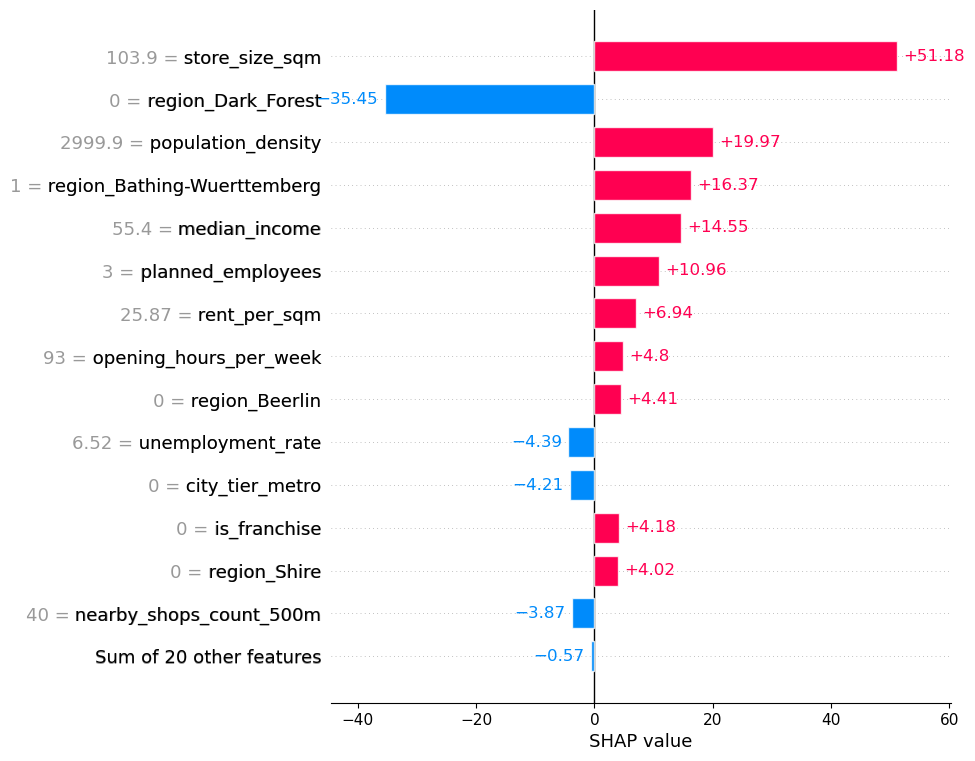

In [37]:
i = 0

# Local bar (matplotlib, reliable)
vals = sv[i]
base = float(np.array(explainer.expected_value).reshape(-1)[0])

exp_local = shap.Explanation(
    values=vals,
    base_values=base,
    data=X_exp.iloc[i].values,
    feature_names=X_exp.columns.tolist()
)

shap.plots.bar(exp_local, max_display=15)
plt.show()

In [38]:
print("=== Why we chose median_income ===")
print("- It is highly interpretable for the retail location problem and shows strong association with annual_profit in this dataset.")
print("- The SHAP dependence plot shows how median_income changes the model prediction across many stores (not just a single correlation number).")

print("\n=== Why SHAP is best here ===")
print("- The underlying model is XGBoost (tree-based), and TreeExplainer is designed for tree models.")
print("- SHAP provides both global explanations (overall drivers) and local explanations (single-store reasoning) with one consistent framework.")

=== Why we chose median_income ===
- It is highly interpretable for the retail location problem and shows strong association with annual_profit in this dataset.
- The SHAP dependence plot shows how median_income changes the model prediction across many stores (not just a single correlation number).

=== Why SHAP is best here ===
- The underlying model is XGBoost (tree-based), and TreeExplainer is designed for tree models.
- SHAP provides both global explanations (overall drivers) and local explanations (single-store reasoning) with one consistent framework.
